# End-to-End Machine Learning Exercise


**Prepared by:** **Ali H. El-Kassas**  
*Senior Data Scientist | Machine Learning Instructor*

This notebook is intended to help students practice the complete machine learning workflow, including exploratory data analysis, data preprocessing, feature engineering, model training, hyperparameter tuning, and error analysis.

Complete all `TODO` sections.

### Objectives

Build a machine learning pipeline that predicts the Manufacturer Suggested Retail Price (MSRP) of a car.

- Frame the problem
- Select a Performance Measure
- Quick look on the data
- Train/Validation/Test split
- EDA
- Preprocessing
- Pipelines
- Modeling
- Fine-Tuning
- Error Analysis
- Final Evaluation
- Deploy the model

In [1]:
# TODO Import all the lib that you need here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time 
import joblib

from sklearn.model_selection import(train_test_split, GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [3]:
# TODO: Load the dataset
import pandas as pd
df = pd.read_csv("data.csv")

In [4]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## Initial Inspection
Inspect shape, dtypes, missing values, duplicates and descriptive statistics.

In [5]:
df.shape

(11914, 16)

In [6]:
# TODO
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [7]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(715)

In [9]:
# TODO
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [105]:
df.describe(include=["object", "string"])

,Make,Model,Engine Fuel Type,Transmission Type,Driven_Wheels,Market Category,Vehicle Size,Vehicle Style
count,11199,11199,11196,11199,11199,7823,11199,11199
unique,48,915,10,5,4,71,3,16
top,Chevrolet,Silverado 1500,regular unleaded,AUTOMATIC,front wheel drive,Crossover,Compact,Sedan
freq,1083,156,6658,7932,4354,1075,4395,2843


In [106]:
df = df.drop_duplicates()
df.shape

(11199, 16)

In [107]:
df["Make"].value_counts()

Make
Chevrolet        1083
Ford              825
Toyota            719
Volkswagen        568
Nissan            551
Dodge             529
GMC               482
Honda             433
Mazda             412
Cadillac          396
Suzuki            342
Mercedes-Benz     341
Infiniti          328
BMW               324
Audi              321
Volvo             266
Hyundai           259
Acura             246
Subaru            239
Kia               229
Mitsubishi        208
Lexus             202
Buick             190
Chrysler          187
Pontiac           181
Lincoln           160
Land Rover        139
Porsche           136
Oldsmobile        132
Saab              109
Aston Martin       91
Bentley            74
Plymouth           71
Ferrari            69
FIAT               62
Scion              60
Maserati           55
Lamborghini        52
Rolls-Royce        31
Lotus              28
Tesla              18
HUMMER             17
Maybach            16
Alfa Romeo          5
McLaren             5
Genes

In [108]:
df['Model'].unique()

<ArrowStringArray>
[  '1 Series M',     '1 Series',          '100',   '124 Spider',
    '190-Class',     '2 Series',          '200',        '200SX',
        '240SX',          '240',
 ...
 'Yukon Denali', 'Yukon Hybrid',     'Yukon XL',        'Yukon',
           'Z3',         'Z4 M',           'Z4',           'Z8',
          'ZDX',       'Zephyr']
Length: 915, dtype: str

In [109]:
df['Transmission Type'].value_counts()

Transmission Type
AUTOMATIC           7932
MANUAL              2634
AUTOMATED_MANUAL     553
DIRECT_DRIVE          68
UNKNOWN               12
Name: count, dtype: int64

## Train / Validation / Test Split
Split data into Train, Validation and Test sets.

In [110]:
# TODO separating test set
from sklearn.model_selection import train_test_split

training_validation, testing = train_test_split(df, test_size=0.2, random_state=42)



In [111]:
training, validation = train_test_split(training_validation, test_size=0.25, random_state=42)

In [112]:
print("Training:", training.shape)
print("Validation:", validation.shape)
print("Testing:", testing.shape)

Training: (6719, 16)
Validation: (2240, 16)
Testing: (2240, 16)


## Exploratory Data Analysis

### Numerical Features



- Histograms
- KDE plots
- Boxplots
- Distribution of MSRP
- Identify skewed features

In [113]:
# TODO
numerical_columns = df.select_dtypes(include=np.number).columns
numerical_columns

Index(['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

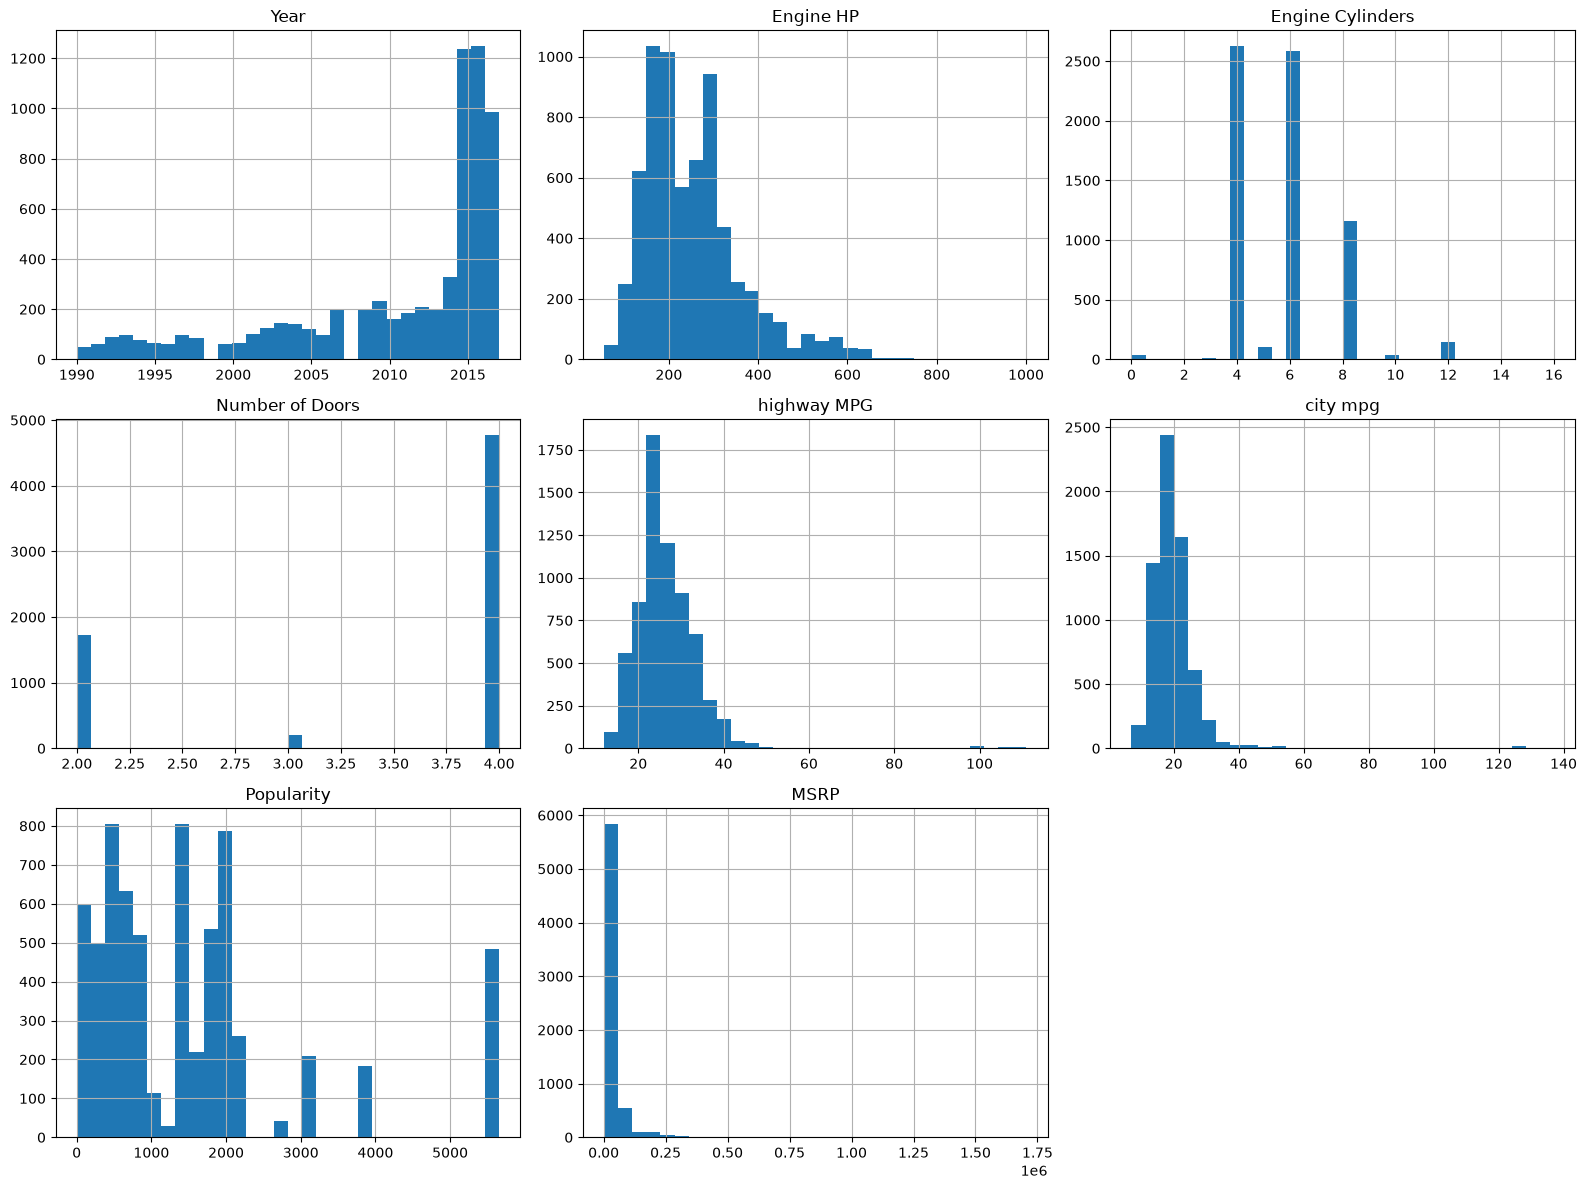

In [114]:
training[numerical_columns].hist( bins=30, figsize=(16, 12))

plt.tight_layout()
plt.show()

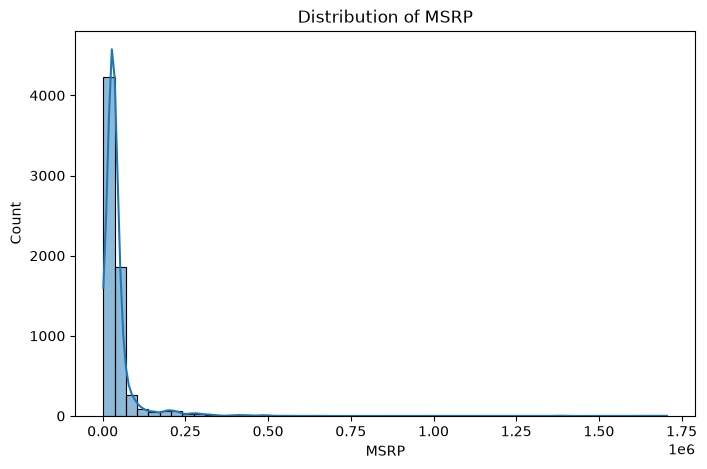

In [115]:
plt.figure(figsize=(8, 5))

sns.histplot(data=training, x="MSRP", bins=50, kde= True)

plt.title("Distribution of MSRP")
plt.show()

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


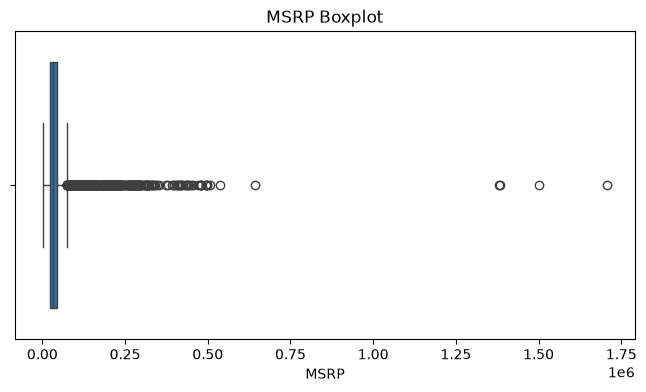

In [116]:
plt.figure(figsize=(8, 4))
sns. boxplot, vertical, horizontal(data = training, x = "MSRP")

plt.title("MSRP Boxplot")
plt.show()

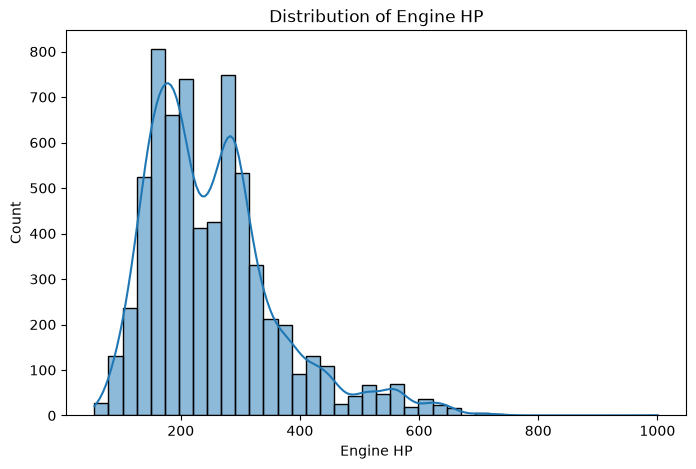

In [117]:
plt.figure(figsize=(8, 5))

sns.histplot(data=training, x="Engine HP", bins=40, kde=True)
plt.title("Distribution of Engine HP")
plt.show()

## Outlier Detection


- Identify outliers using boxplots
- Decide whether to remove them and explain why?

In [118]:
# TODO
outlier_columns = ["Engine HP", "Engine Cylinders", 
                   "highway MPG", "city mpg", "Popularity", "MSRP"]

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


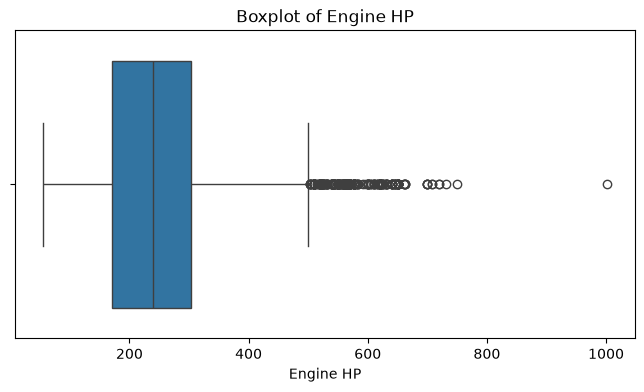

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


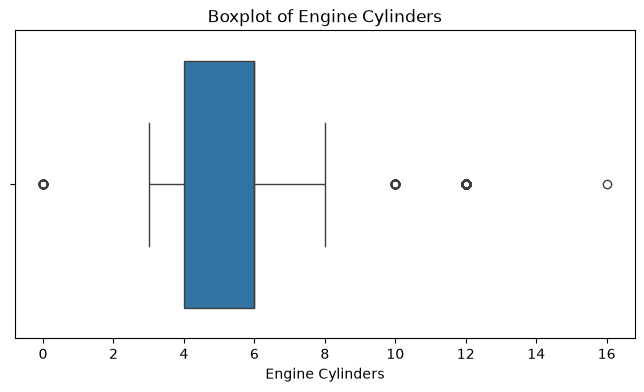

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


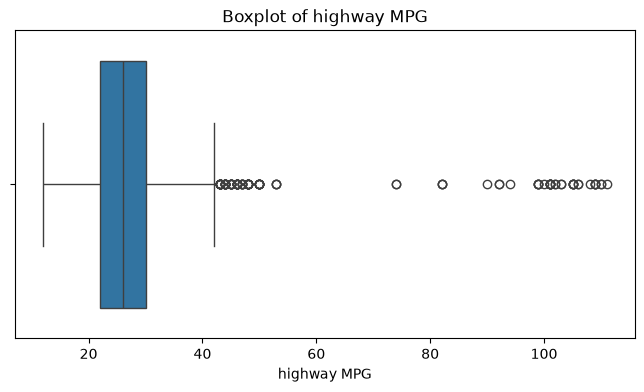

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


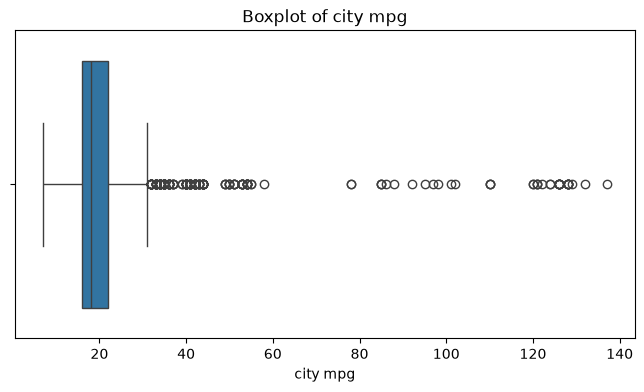

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


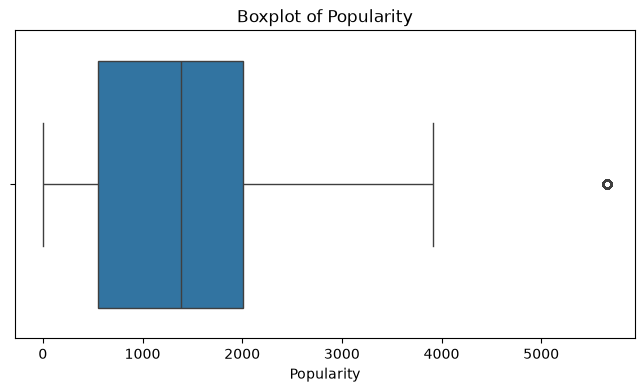

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


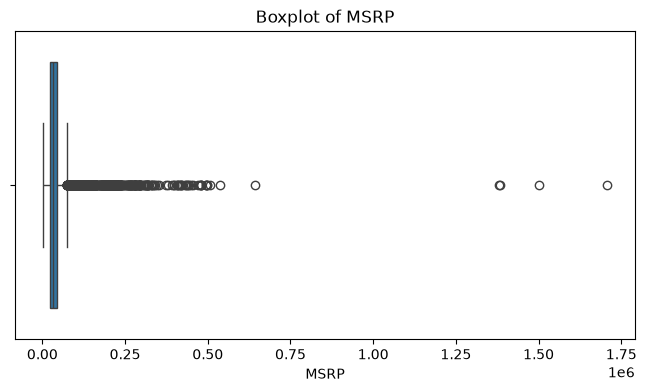

In [129]:
for column in outlier_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=training, x=column)
    plt.title(f"Boxplot of {column}")
    plt.show()

### Categorical Features



- Countplots
- Number of unique values

In [130]:
# TODO
catagorical_columns = training.select_dtypes(include=["object", "string"]).columns

training[catagorical_columns].nunique().sort_values()



Vehicle Size           3
Driven_Wheels          4
Transmission Type      5
Engine Fuel Type      10
Vehicle Style         16
Make                  48
Market Category       68
Model                870
dtype: int64

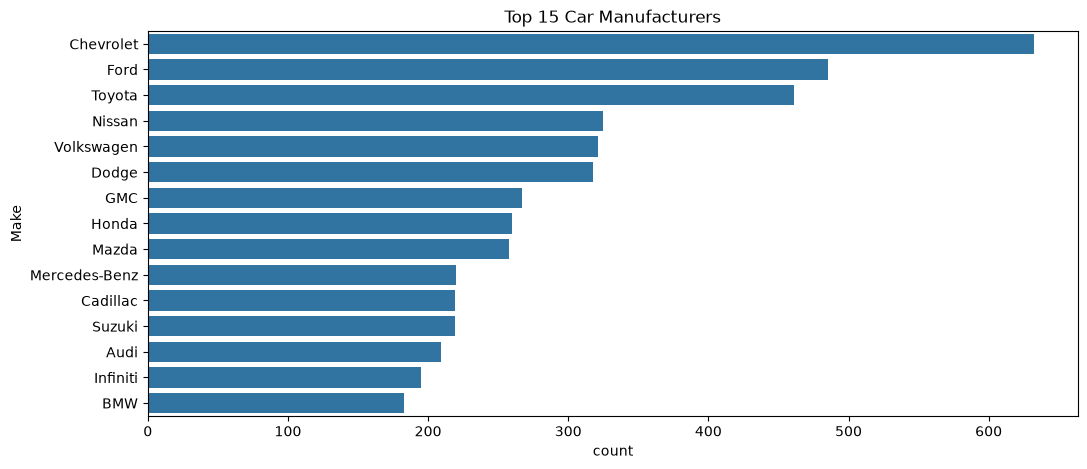

In [131]:
plt.figure(figsize=(12, 5))

sns.countplot(data= training, y="Make", 
              order=training["Make"].value_counts().head(15).index)
plt.title("Top 15 Car Manufacturers")
plt.show()

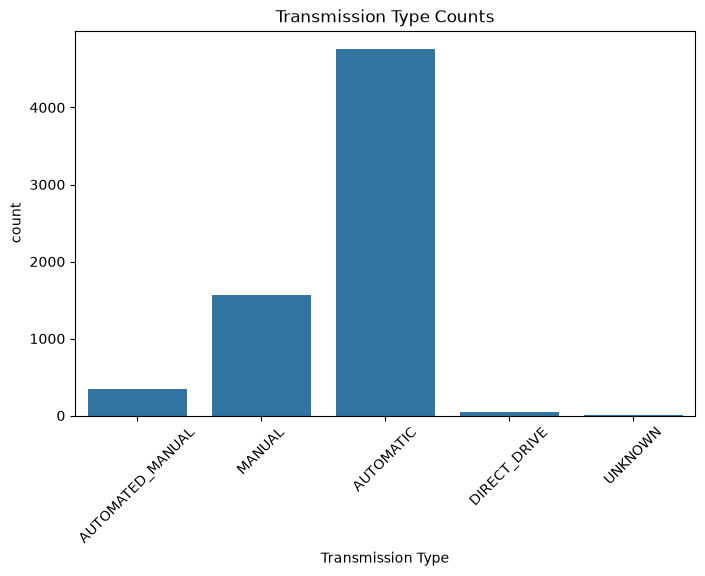

In [132]:
plt.figure(figsize=(8, 5))
sns.countplot(data= training, x="Transmission Type")

plt.xticks(rotation=45)
plt.title("Transmission Type Counts")
plt.show()

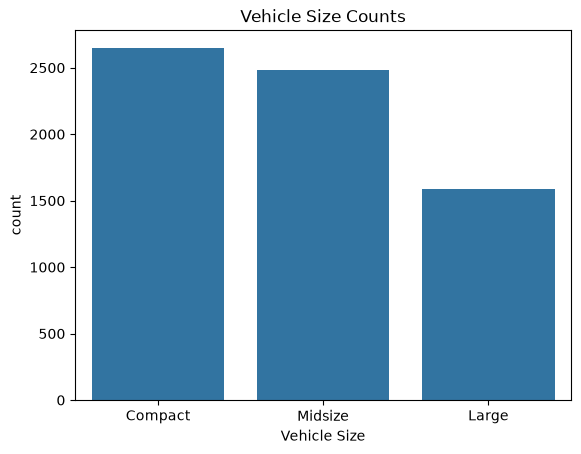

In [133]:
sns.countplot(data=training, x="Vehicle Size")
plt.title("Vehicle Size Counts")
plt.show()

### Relationship with Target

Tasks

- Scatterplots
- Correlation heatmap
- Pairplots (selected columns)


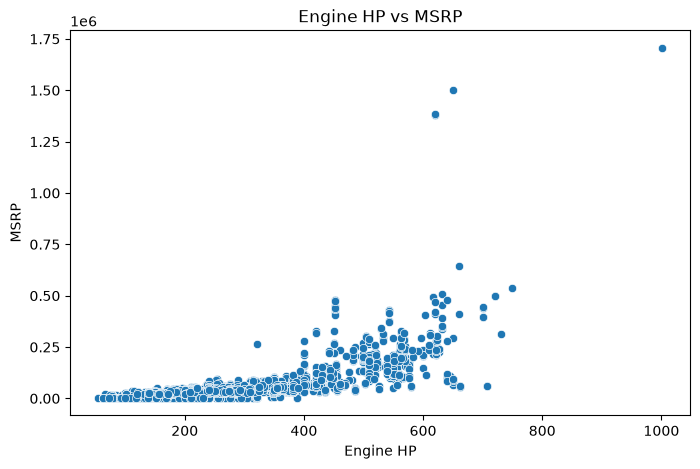

In [134]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=training, x="Engine HP", y="MSRP")

plt.title("Engine HP vs MSRP")
plt.show()

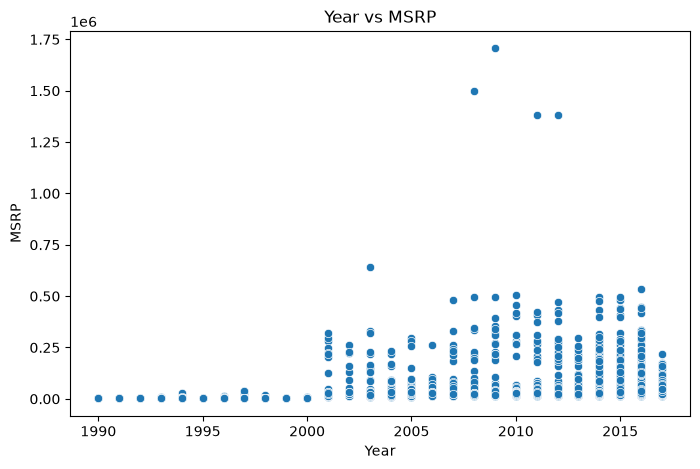

In [135]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=training,
    x="Year",
    y="MSRP"
)

plt.title("Year vs MSRP")
plt.show()

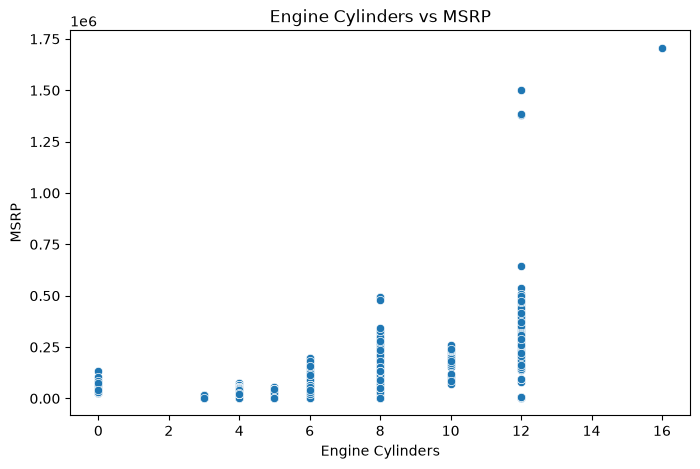

In [136]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=training, x="Engine Cylinders", y="MSRP")

plt.title("Engine Cylinders vs MSRP")
plt.show()

In [137]:
# TODO
corr_matrix = training.select_dtypes(include=np.number).corr()

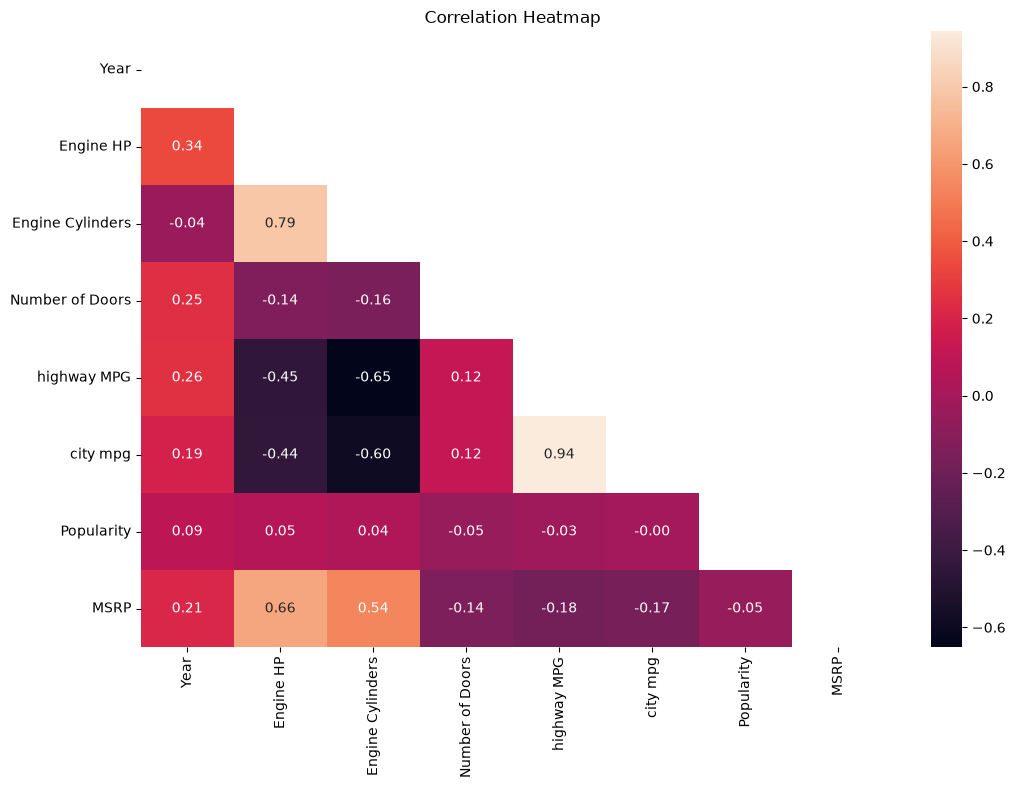

In [138]:
plt.figure(figsize=(12, 8))

mask= np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [139]:
corr_matrix["MSRP"].sort_values(ascending=False)

MSRP                1.000000
Engine HP           0.658753
Engine Cylinders    0.542906
Year                0.208764
Popularity         -0.047453
Number of Doors    -0.142429
city mpg           -0.166413
highway MPG        -0.183226
Name: MSRP, dtype: float64

In [140]:
pairplot_columns = ["MSRP", "Engine HP", 
                    "Engine Cylinders", "Year", "highway MPG", "city mpg"]

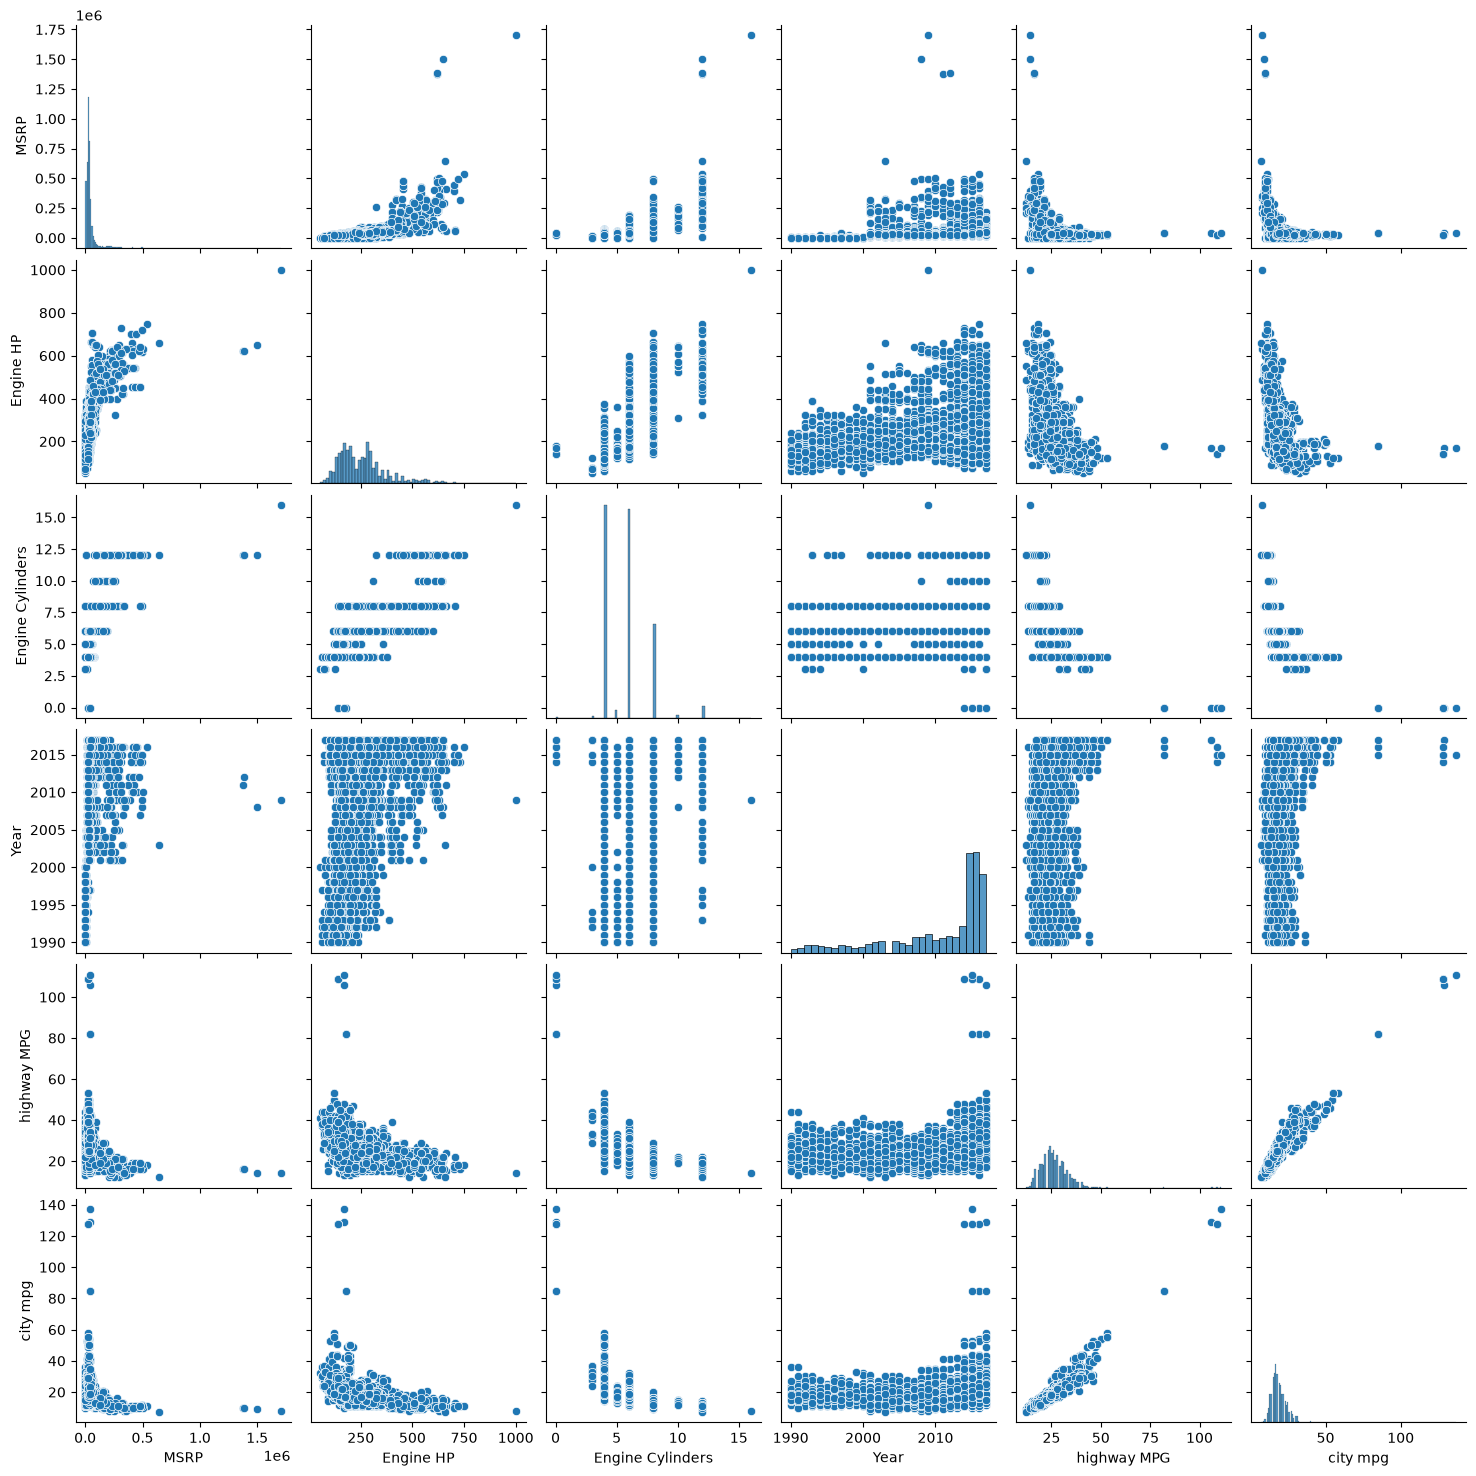

In [141]:
sns.pairplot(training[pairplot_columns].dropna())
plt.show()

Questions:

- Which features seem most correlated with price?

In [142]:
# TODO - No Code

#Enggine HP is most strongly related to MSRP.
#Engine Cylinders and Year also have positive relationships.
#MPG has a weaker relashionship, while Make and Vehicle style may also affect price.



## Feature Engineering
Create at least two new features that may improve performance.

Possible ideas

- Engine HP per Cylinder

- Power-to-weight proxy


**You should do the same step for the `val` and `test`**

In [143]:
# TODO
def create_new_features(data):
    data = data.copy()
    data["HP per Cylinder"] = (data["Engine HP"]/ data["Engine Cylinders"].replace(0, np.nan))

    data["MPG Average"] = (data["highway MPG"] + data["city mpg"]) / 2
    return data

In [144]:
training = create_new_features(training)
validation = create_new_features(validation)
testing = create_new_features(testing)

In [145]:
training[["Engine HP", "Engine Cylinders", 
          "HP per Cylinder", "highway MPG", "city mpg", "MPG Average"]].head()

,Engine HP,Engine Cylinders,HP per Cylinder,highway MPG,city mpg,MPG Average
1870,210.0,4.0,52.500000,31,23,27.0
10392,172.0,6.0,28.666667,24,16,20.0
2721,268.0,6.0,44.666667,25,17,21.0
11855,355.0,8.0,44.375000,22,15,18.5
4305,297.0,6.0,49.500000,24,17,20.5


# HP per Cylinder
Engine HP ÷ Engine Cylinders 

# MPG Average
(highway MPG + city mpg) ÷ 2 

In [146]:
feature_columns = ["Year", "Engine HP", "Engine Cylinders", "Number of Doors", 
                   "highway MPG", "city mpg", "Popularity", "HP per Cylinder", "MPG Average", 
                   "Make", "Engine Fuel Type", "Transmission Type", "Driven_Wheels", 
                   "Vehicle Size", "Vehicle Style"]

In [147]:
X_train = training[feature_columns]
y_train = training["MSRP"]

X_validation = validation[feature_columns]
y_validation = validation["MSRP"]

X_test = testing[feature_columns]
y_test = testing["MSRP"]

## Preprocessing
Identify numerical and categorical columns and build a ColumnTransformer.

In [148]:
# TODO
numerical_features = X_train.select_dtypes(include= np.number).columns.tolist()

In [149]:
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

In [150]:
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity', 'HP per Cylinder', 'MPG Average']

Categorical features:
['Make', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Vehicle Size', 'Vehicle Style']


## Pipeline
Create a preprocessing + model pipeline.

In [151]:
# TODO
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (MinMaxScaler, OneHotEncoder)

numerical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),
                               ("scaler",MinMaxScaler())])

In [152]:
categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                               ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

In [153]:
preprocessor = ColumnTransformer([("numerical", numerical_pipeline, numerical_features), 
                                  ("categorical", categorical_pipeline, categorical_features)])

In [154]:
linear_pipeline = Pipeline([("preprocessor", preprocessor), 
                            ("model", LinearRegression())])

In [155]:
linear_pipeline.fit(X_train, y_train) 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Year','Engine HP','Engine Cylinders',...,'Driven_Wheels','Vehicle Size', 'Vehicle Style']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pass

In [156]:
linear_predictions = linear_pipeline.predict(X_validation)

## Baseline Model
Train a Linear Regression model and evaluate using MAE, RMSE and MSE.

In [157]:
# TODO
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score) 

linear_mae = mean_absolute_error(y_validation, linear_predictions)
linear_mse = mean_squared_error(y_validation, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_validation, linear_predictions)

In [158]:
print("Linear Regression MAE:", linear_mae)
print("Linear Regression MSE:", linear_mse)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R-squared:", linear_r2)

Linear Regression MAE: 9820.1255152329
Linear Regression MSE: 393729419.56571007
Linear Regression RMSE: 19842.616248007973
Linear Regression R-squared: 0.8518231620926279


How well does Linear Regression perform?

In [160]:
# TODO 
#The model's average prediction error is about $9,820.
#It explains around 85% of the variation in car prices.
#Same Larger prediction errors still occur, especially for unusual cars.
#Interpretatio

## Model Comparison
Compare at least two regression models.

In [161]:
# TODO
tree_pipeline = Pipeline([("preprocessor", preprocessor), 
                          ("model", DecisionTreeRegressor( max_depth=12, random_state=42))])

In [162]:
tree_pipeline.fit(X_train, y_train)
tree_predictions = tree_pipeline.predict(X_validation)

In [163]:
forest_pipeline = Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1))])

In [164]:
forest_pipeline.fit(X_train, y_train)
forest_predictions = forest_pipeline.predict(X_validation)

In [165]:
def evaluate_model(model_name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)
    return {"Model": model_name, 
    "MAE": mae, 
    "MSE": mse, 
    "RMSE": rmse, 
    "R_squared": r2}
    
    

In [166]:
model_results = [evaluate_model("Linear Regression", y_validation, linear_predictions),
                evaluate_model("Decision Tree", y_validation, tree_predictions), 
                evaluate_model("Random Forest", y_validation, forest_predictions)]

In [167]:
results_df = pd.DataFrame(model_results)
results_df.sort_values("MAE")

,Model,MAE,MSE,RMSE,R_squared
2,Random Forest,3805.874679,1.117828e+08,10572.736346,0.957931
1,Decision Tree,4920.686258,1.551286e+08,12455.063411,0.941619
0,Linear Regression,9820.125515,3.937294e+08,19842.616248,0.851823


## Hyperparameter Tuning
Tune your best model using GridSearchCV.

In [168]:
import time
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline


In [169]:
forest_tuning_pipeline = Pipeline([("preprocessor", preprocessor),
                          ("model", RandomForestRegressor(random_state=42, n_jobs=-1))])
forest_tuning_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, def

In [170]:
# TODO
parameter_grid = {"model__n_estimators": [50, 100], 
                  "model__max_depth":[10, 20, None],
                  "model__min_samples_split": [2, 5]}

In [171]:
grid_search = GridSearchCV(estimator = forest_tuning_pipeline, param_grid = parameter_grid, 
                           cv=3, scoring="neg_mean_absolute_error",n_jobs = -1)
grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ver

In [172]:
grid_start_time = time.time()
grid_search.fit(X_train, y_train)

grid_time= time.time() - grid_start_time

In [173]:
print("Best parameters:")
print(grid_search.best_params_)

print("Best cross-validation MAE:")
print(-grid_search.best_score_)

print("Grid Search time:")
print(grid_time) 

#finish

Best parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best cross-validation MAE:
4586.1884861371145
Grid Search time:
254.98491024971008


Repeat using RandomizedSearchCV.

In [174]:
random_search = RandomizedSearchCV(estimator = forest_tuning_pipeline, param_distributions = parameter_grid, 
                                    n_iter=5, cv=3, scoring="neg_mean_absolute_error", random_state=42, n_jobs=-1)

In [175]:
random_start_time = time.time()
random_search.fit(X_train, y_train)

random_time= time.time() - random_start_time

In [176]:
print("Best parameters:")
print(random_search.best_params_)

print("Best cross-validation MAE:")
print(-random_search.best_score_)

print("Random Search time:")
print(random_time)

Best parameters:
{'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__max_depth': None}
Best cross-validation MAE:
4586.1884861371145
Random Search time:
87.0733380317688


Which method was faster? Did both produce similar results?

In [177]:
# TODO

print("Grid Search time:", grid_time)
print("Random Search time:", random_time)

Grid Search time: 254.98491024971008
Random Search time: 87.0733380317688


In [212]:
#RandomizedSearchCV was generally faster because it tested only five randomly selected parameter combinations.

In [179]:
best_model = grid_search.best_estimator_

In [180]:
best_validation_predictions = best_model.predict(X_validation)

In [181]:
best_validation_mae = mean_absolute_error(y_validation, best_validation_predictions)
best_validation_rmse = np.sqrt(mean_squared_error(y_validation, best_validation_predictions))
best_validation_r2 = r2_score(y_validation, best_validation_predictions)

In [182]:
print("validation MAE:", best_validation_mae)
print("validation RMSE:", best_validation_rmse)
print("validation R-squared:", best_validation_r2)

validation MAE: 3807.9489111494463
validation RMSE: 9935.146189243309
validation R-squared: 0.9628523812392485


## Error Analysis (Bonus)

Predict on validation set

In [183]:
# TODO
error_analysis = validation.copy()

In [184]:
error_analysis["Predicted MSRP"] = (best_validation_predictions)

Compute residuals

`Actual - Predicted`

In [185]:
# TODO
error_analysis["Residual"] = (error_analysis["MSRP"] - error_analysis["Predicted MSRP"]) 

In [186]:
error_analysis["Absolute Error"] = (error_analysis["Residual"].abs())

Plot residuals, Predicted vs Actual, investigate largest errors.

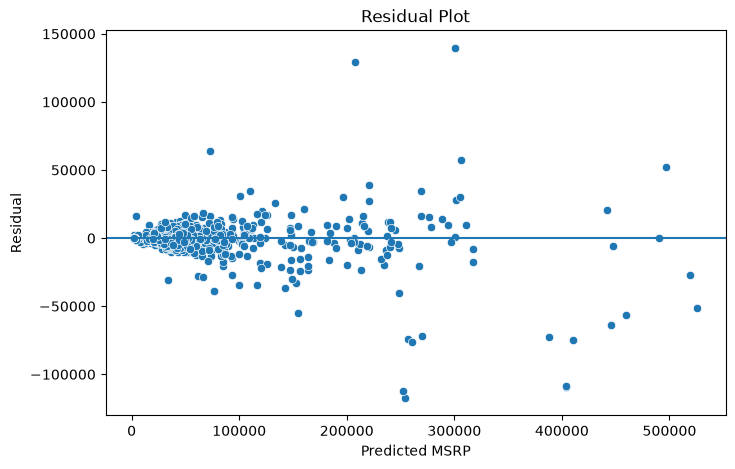

In [187]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=error_analysis, x="Predicted MSRP", y="Residual")

plt.axhline(y=0)

plt.title("Residual Plot")
plt.show()

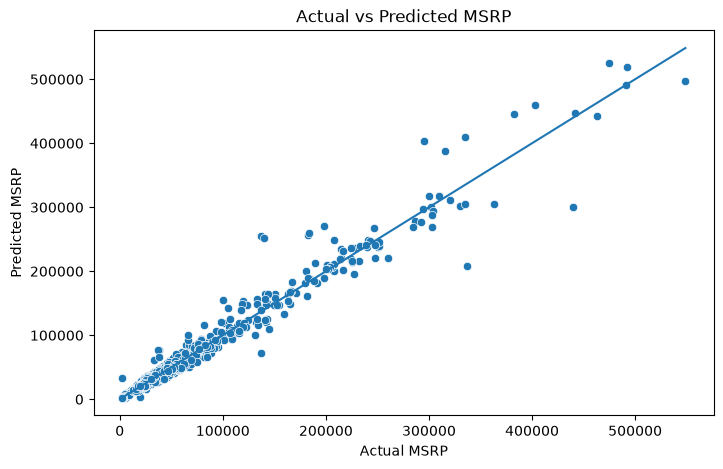

In [188]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=error_analysis, x="MSRP", y="Predicted MSRP")

minimum_price = error_analysis["MSRP"].min()
maximum_price = error_analysis["MSRP"].max()

plt.plot([minimum_price, maximum_price], [minimum_price, maximum_price])

plt.xlabel("Actual MSRP")
plt.ylabel("Predicted MSRP")
plt.title("Actual vs Predicted MSRP")
plt.show()

- Where does the model fail?

In [189]:
#TODO-NO CODE
# Residuals should be randomly scattered around zero.
# points far from the line indicate larger prediction errors.


Which cars have the highest prediction errors?

In [190]:
#TODO-NO CODE
#The largest error generally occur for unusually expensive, luxury, rare, or high-performance vehicles. these cars have prices that may depend on brand prestige, special editions, optional equipment, or rarity, which are not fully by the availabe features.


Are expensive cars harder to predict?

In [191]:
#TODO-NO CODE
# Expensive cars are harder to predict due to greater price variation.

## Final Test Evaluation
Evaluate **only once** on the held-out test set.

In [192]:
# TODO
full_training = pd.concat([training, validation])

In [193]:
X_full_training = full_training[feature_columns]
y_full_training = full_training["MSRP"]

In [194]:
best_model.fit(X_full_training, y_full_training)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Year','Engine HP','Engine Cylinders',...,'Driven_Wheels','Vehicle Size', 'Vehicle Style']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pass

In [195]:
final_test_predictions = best_model.predict(X_test)

In [196]:
final_mae = mean_absolute_error(y_test, final_test_predictions)
final_mse = mean_squared_error(y_test, final_test_predictions)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_test_predictions)

In [197]:
print("Final Test MAE:", final_mae)
print("Final Test MSE:", final_mse)
print("Final Test RMSE:", final_rmse)
print("Final Test R-squared:", final_r2)

Final Test MAE: 3780.2841245185
Final Test MSE: 300799067.8303742
Final Test RMSE: 17343.559837310626
Final Test R-squared: 0.9379167893789929


## Deployment (Bonus)
Deploy your model using streamlit

In [198]:
import joblib 

joblib.dump(best_model, "model.pkl")

print("Model saved successfully!")  

Model saved successfully!


## Reflection
Summarize findings.

- Which preprocessing steps were essential?
- Which model performed best?
- Why?
- Did hyperparameter tuning improve performance?
- Which features contributed most?
- What additional data would improve predictions?
- If this model were deployed in production, what challenges might arise?

In [213]:
# TODO

# 1- Which preprocessing steps were essential?
# Handling misiing values, creating new features, one_hot encoding categorical variables, and scaling numerical features.
# 2 - Which model performed best?
# The tuned random forest regressor preformed best because it captured complex relationships between the features and MSRP.
# 3 - Did hyperparameter tuning improve performance?
# Yes, Hyperparameter tuning improved the model's prediction accuracy compared to the default settings.
# 4 - Which features contributed most?
# Engine HP contributed the most, followed by Engine Cyliders, year, and make.
# 5 - What additional data would improve predictions?
# Vehicle milage, accident history, trim level, condition, and optional features would likely improve accuracy.
# 6 - If this model were deployed in production, what challenges might arise?
# The model may perform less accurately on new or rare car models, and it would need regular updates as car prices and market trends change.

## Bonus Challenges - 1
- Remove outliers and compare. Did performance improve?
  


In [204]:
#TODO
q1 = training["MSRP"].quantile(0.25)
q3 = training["MSRP"].quantile(0.75)

In [205]:
iqr = q3 - q1

In [206]:
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

In [207]:
training_without_outliers = training[(training["MSRP"] >= lower_limit) & (training["MSRP"] <= upper_limit)]

In [208]:
print("Original training rows:", len(training)) 
print("Rows after removing outliers:", len(training_without_outliers))

Original training rows: 6719
Rows after removing outliers: 6135


## Bonus Challenges - 2

Perform feature selection

In [209]:
import os 

print(os.path.exists("model.pkl"))

True


In [210]:
import joblib 

pipe = joblib.load("model.pkl")
print(type(pipe))

<class 'sklearn.pipeline.Pipeline'>


In [211]:
joblib.dump(best_model, "model.pkl")

['model.pkl']